<a href="https://colab.research.google.com/github/studentradhika/Adaptive-Behavioral-Intelligence-System-for-Resource-Utilization-Optimization/blob/main/workload_optimization_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(0)

time = np.arange(0, 50)

before_workload = np.random.randint(20, 100, size=50)

print(before_workload)

[64 67 84 87 87 29 41 56 90 32 78 85 59 66 57 45 97 92 29 40 89 99 67 84
 69 49 39 39 34 59 52 85 29 77 52 51 94 43 55 95 75 48 54 20 20 56 73 25
 58 37]


In [3]:
after_workload = before_workload * 0.8

print(after_workload)

[51.2 53.6 67.2 69.6 69.6 23.2 32.8 44.8 72.  25.6 62.4 68.  47.2 52.8
 45.6 36.  77.6 73.6 23.2 32.  71.2 79.2 53.6 67.2 55.2 39.2 31.2 31.2
 27.2 47.2 41.6 68.  23.2 61.6 41.6 40.8 75.2 34.4 44.  76.  60.  38.4
 43.2 16.  16.  44.8 58.4 20.  46.4 29.6]


In [4]:
def optimize_workload(workload):
    optimized = []
    threshold = 60

    for i in range(len(workload)):
        if workload[i] > threshold:
            optimized.append(threshold + (workload[i] - threshold) * 0.3)
        else:
            if i == 0:
                optimized.append(workload[i])
            else:
                avg = (workload[i] + workload[i-1]) / 2
                optimized.append(avg)

    return np.array(optimized)

NameError: name 'optimized_workload' is not defined

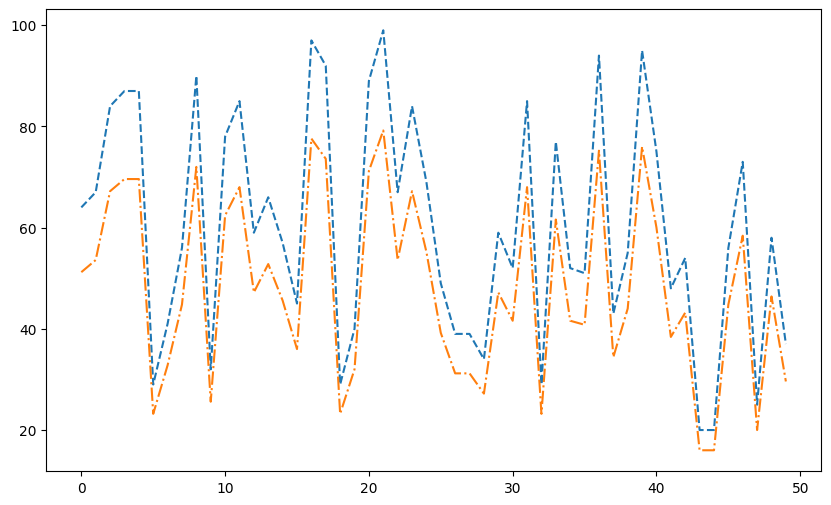

In [5]:
plt.figure(figsize=(10,6))

plt.plot(time, before_workload, linestyle='--', label="Before Workload")
plt.plot(time, after_workload, linestyle='-.', label="After Workload")
plt.plot(time, optimized_workload, linewidth=2, label="Optimized Workload")

plt.xlabel("Time")
plt.ylabel("Resource Usage")
plt.title("Workload Optimization Comparison")

plt.legend()
plt.grid()

plt.show()

In [6]:
!pip install scikit-learn

In [7]:
from sklearn.linear_model import LinearRegression

In [9]:
# recreate optimized_workload quickly

def optimize_workload(workload):
    optimized = []
    threshold = 60

    for i in range(len(workload)):
        if workload[i] > threshold:
            optimized.append(threshold + (workload[i] - threshold) * 0.3)
        else:
            if i == 0:
                optimized.append(workload[i])
            else:
                optimized.append((workload[i] + workload[i-1]) / 2)

    return np.array(optimized)

optimized_workload = optimize_workload(after_workload)

In [10]:
# reshape time for ML
X = time.reshape(-1, 1)

# target = optimized workload
y = optimized_workload

In [11]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [12]:
future_time = np.arange(50, 70).reshape(-1, 1)

predicted_workload = model.predict(future_time)

print(predicted_workload)

[41.63330612 41.33098872 41.02867131 40.7263539  40.42403649 40.12171909
 39.81940168 39.51708427 39.21476687 38.91244946 38.61013205 38.30781465
 38.00549724 37.70317983 37.40086242 37.09854502 36.79622761 36.4939102
 36.1915928  35.88927539]


In [13]:
def smart_optimize(predicted):
    smart = []
    threshold = 60

    for val in predicted:
        if val > threshold:
            smart.append(threshold + (val - threshold) * 0.2)
        else:
            smart.append(val * 0.95)  # slight smoothing

    return np.array(smart)

smart_workload = smart_optimize(predicted_workload)

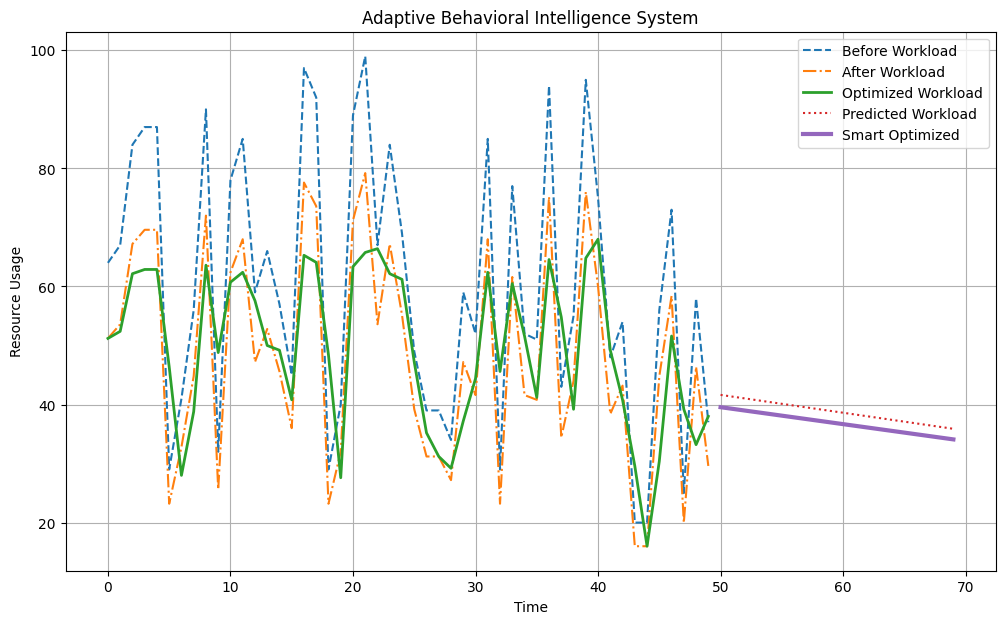

In [14]:
plt.figure(figsize=(12,7))

# existing
plt.plot(time, before_workload, linestyle='--', label="Before Workload")
plt.plot(time, after_workload, linestyle='-.', label="After Workload")
plt.plot(time, optimized_workload, linewidth=2, label="Optimized Workload")

# future prediction
plt.plot(future_time, predicted_workload, linestyle=':', label="Predicted Workload")

# smart optimized future
plt.plot(future_time, smart_workload, linewidth=3, label="Smart Optimized")

plt.xlabel("Time")
plt.ylabel("Resource Usage")
plt.title("Adaptive Behavioral Intelligence System")

plt.legend()
plt.grid()

plt.show()